In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import random
from tqdm import tqdm
torch.backends.cuda.enable_flash_sdp(False)
torch.backends.cuda.enable_mem_efficient_sdp(False)
torch.backends.cuda.enable_math_sdp(True)

In [4]:
def set_seed(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

In [5]:
p = 100   # common choice in grokking experiments

def generate_dataset(p):

    xs = []
    ys = []

    for i in range(p):
        for j in range(p):

            xs.append([i, j])
            ys.append((i + j) % p)

    xs = torch.tensor(xs)
    ys = torch.tensor(ys)

    return xs, ys

In [6]:
def train_val_split(xs, ys):

    N = xs.shape[0]
    idx = torch.randperm(N)

    split = N // 2

    train_idx = idx[:split]
    val_idx = idx[split:]

    return (
        xs[train_idx], ys[train_idx],
        xs[val_idx], ys[val_idx]
    )

In [7]:
class TransformerModel(nn.Module):

    def __init__(self, p, d_model=128, nhead=4, num_layers=2):

        super().__init__()

        self.p = p
        self.d_model = d_model

        # token embeddings
        self.token_embedding = nn.Embedding(p, d_model)

        # positional embeddings
        self.pos_embedding = nn.Embedding(2, d_model)

        # transformer encoder layer
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=4*d_model,
            dropout=0.0,              # IMPORTANT
            activation="relu",
            batch_first=True,
            norm_first=False          # matches PyTorch default used in reproductions
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        # final classifier
        self.output = nn.Linear(d_model, p)

    def forward(self, x, return_hidden=False):

        B, T = x.shape

        # positional indices
        pos = torch.arange(T, device=x.device).unsqueeze(0).repeat(B,1)

        # embeddings
        x = self.token_embedding(x) + self.pos_embedding(pos)

        # transformer
        h = self.transformer(x)

        # use final token representation
        h_final = h[:, -1]

        logits = self.output(h_final)

        if return_hidden:
            return logits, h_final

        return logits

In [8]:
def accuracy(logits, y):

    preds = torch.argmax(logits, dim=1)

    return (preds == y).float().mean().item()

In [9]:
# def compute_ncc(representations, labels):

#     reps = representations.detach().cpu().numpy()
#     labels = labels.cpu().numpy()

#     mu = reps.mean(axis=0)

#     numerator = 0
#     denominator = 0

#     for c in np.unique(labels):

#         class_reps = reps[labels == c]

#         mu_c = class_reps.mean(axis=0)

#         numerator += ((class_reps - mu_c)**2).sum()
#         denominator += ((mu_c - mu)**2).sum()

#     return numerator / denominator


def compute_ncc(representations, labels):
    """
    Neural Collapse Clustering metric used in the paper.
    Pairwise class clustering ratio.
    """

    class_dict = {key.item(): [] for key in torch.unique(labels)}

    for rep, label in zip(representations, labels):
        class_dict[label.item()].append(rep)

    mean_var_dict = {}

    for key, value in class_dict.items():
        value = torch.stack(value)

        mu = torch.mean(value, dim=0)
        var = torch.mean(torch.stack([torch.linalg.norm(f - mu) ** 2 for f in value]))

        mean_var_dict[key] = (mu, var)

    pairwise_vals = []

    classes = list(mean_var_dict.keys())

    for i in range(len(classes)):
        for j in range(len(classes)):

            if i == j:
                continue

            mu1, var1 = mean_var_dict[classes[i]]
            mu2, var2 = mean_var_dict[classes[j]]

            val = (var1 + var2) / (2 * torch.linalg.norm(mu1 - mu2) ** 2)

            pairwise_vals.append(val)

    ncc = torch.mean(torch.stack(pairwise_vals))

    return ncc.item()

In [10]:
# def compute_relative_flatness(model, loss_fn, xs, ys, eps=1e-3):

#     with torch.no_grad():

#         logits = model(xs)
#         original_loss = loss_fn(logits, ys)

#         backup = [p.clone() for p in model.parameters()]

#         for p in model.parameters():
#             p += eps * torch.randn_like(p)

#         logits = model(xs)
#         perturbed_loss = loss_fn(logits, ys)

#         for p, b in zip(model.parameters(), backup):
#             p.copy_(b)

#     rf = (perturbed_loss - original_loss) / original_loss

#     return rf.item()
def compute_relative_flatness(model, features, logits):

    logits = logits.float()   # important fix

    probs = torch.softmax(logits, dim=1)

    hessian_first = torch.sum(probs * (1 - probs), dim=1)

    hessian_second = torch.sum(features * features, dim=1)

    W = model.output.weight
    weights_norm = torch.linalg.norm(W)

    hessian = hessian_first * hessian_second

    sharpness2 = weights_norm * weights_norm * hessian

    return torch.mean(sharpness2).item()

In [11]:
def sharpness(model, loss_fn, X, Y, epsilon=1e-3):

    original = [p.clone() for p in model.parameters()]

    loss1 = loss_fn(model(X), Y)

    with torch.no_grad():
        for p in model.parameters():
            p.add_(epsilon * torch.randn_like(p))

    loss2 = loss_fn(model(X), Y)

    with torch.no_grad():
        for p,o in zip(model.parameters(), original):
            p.copy_(o)

    return (loss2 - loss1).item()



In [12]:
def margin(logits, Y):

    correct = logits[range(len(Y)), Y]

    wrong = logits.clone()
    wrong[range(len(Y)), Y] = -1e9

    max_wrong = wrong.max(dim=1).values

    return (correct - max_wrong).mean().item()


In [13]:
def hessian_trace(model, loss):

    trace = 0

    grads = torch.autograd.grad(loss, model.parameters(), create_graph=True)

    for g in grads:

        v = torch.randn_like(g)

        hv = torch.autograd.grad(
            g,
            model.parameters(),
            grad_outputs=v,
            retain_graph=True,
            allow_unused=True
        )

        trace += sum((h*v).sum() for h,v in zip(hv, model.parameters()) if h is not None)

    return trace.item()

In [14]:
def fisher_trace(model, loss):

    grads = torch.autograd.grad(loss, model.parameters())

    total = 0

    for g in grads:
        total += (g**2).sum()

    return total.item()

In [15]:
def pacbayes_flatness(model, loss_fn, X, Y, sigma=1e-3, samples=5):

    base = loss_fn(model(X), Y)

    losses = []

    for _ in range(samples):

        noise = []

        with torch.no_grad():
            for p in model.parameters():
                eps = sigma * torch.randn_like(p)
                p.add_(eps)
                noise.append(eps)

        loss = loss_fn(model(X), Y)
        losses.append(loss.item())

        with torch.no_grad():
            for p,eps in zip(model.parameters(), noise):
                p.sub_(eps)

    return np.mean(losses) - base.item()


In [16]:
def local_entropy(model, loss_fn, X, Y, beta=10, samples=5):

    vals = []

    original = [p.clone() for p in model.parameters()]

    for _ in range(samples):

        with torch.no_grad():
            for p in model.parameters():
                p.add_(0.01 * torch.randn_like(p))

        loss = loss_fn(model(X), Y)
        vals.append(np.exp(-beta * loss.item()))

        with torch.no_grad():
            for p,o in zip(model.parameters(), original):
                p.copy_(o)

    return -np.log(np.mean(vals))

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [18]:
def train(seed):

    set_seed(seed)

    xs, ys = generate_dataset(p)
    x_train, y_train, x_val, y_val = train_val_split(xs, ys)

    device = "cuda" if torch.cuda.is_available() else "cpu"

    model = TransformerModel(p).to(device)

    x_train = x_train.to(device)
    y_train = y_train.to(device)

    x_val = x_val.to(device)
    y_val = y_val.to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=1e-4,
        weight_decay=1.0
    )

    loss_fn = nn.CrossEntropyLoss()

    train_accs=[]
    val_accs=[]
    nccs=[]
    flatness=[]

    margins=[]
    hessian_vals=[]
    fisher_vals=[]
    pac_vals=[]
    entropy_vals=[]

    steps = 200000

    for step in tqdm(range(steps)):

        logits, hidden = model(x_train, return_hidden=True)

        loss = loss_fn(logits, y_train)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if step % 100 == 0:

            # metrics needing gradients
            val_logits, val_hidden = model(x_val, return_hidden=True)

            loss_val = loss_fn(val_logits, y_val)

            h_trace = hessian_trace(model, loss_val)
            fisher  = fisher_trace(model, loss_val)
            pac     = pacbayes_flatness(model, loss_fn, x_val, y_val)
            ent     = local_entropy(model, loss_fn, x_val, y_val)

            # metrics not needing gradients
            with torch.no_grad():

                train_acc = accuracy(logits, y_train)
                val_acc   = accuracy(val_logits, y_val)

                ncc = compute_ncc(val_hidden, y_val)

                rf = compute_relative_flatness(
                    model,
                    val_hidden,
                    val_logits
                )

                m = margin(val_logits, y_val)

            train_accs.append(train_acc)
            val_accs.append(val_acc)
            nccs.append(ncc)
            flatness.append(rf)

            margins.append(m)
            hessian_vals.append(h_trace)
            fisher_vals.append(fisher)
            pac_vals.append(pac)
            entropy_vals.append(ent)

    return (
        train_accs,
        val_accs,
        nccs,
        flatness,
        margins,
        hessian_vals,
        fisher_vals,
        pac_vals,
        entropy_vals
    )

In [19]:
results = []

for seed in [0]:

    r = train(seed)

    results.append(r)

100%|██████████| 200000/200000 [1:38:59<00:00, 33.67it/s]  


In [20]:
train_acc = np.mean([r[0] for r in results], axis=0)
val_acc   = np.mean([r[1] for r in results], axis=0)
ncc       = np.mean([r[2] for r in results], axis=0)
flatness  = np.mean([r[3] for r in results], axis=0)

margin_vals = np.mean([r[4] for r in results], axis=0)
hessian_vals = np.mean([r[5] for r in results], axis=0)
fisher_vals = np.mean([r[6] for r in results], axis=0)
pac_vals = np.mean([r[7] for r in results], axis=0)
entropy_vals = np.mean([r[8] for r in results], axis=0)

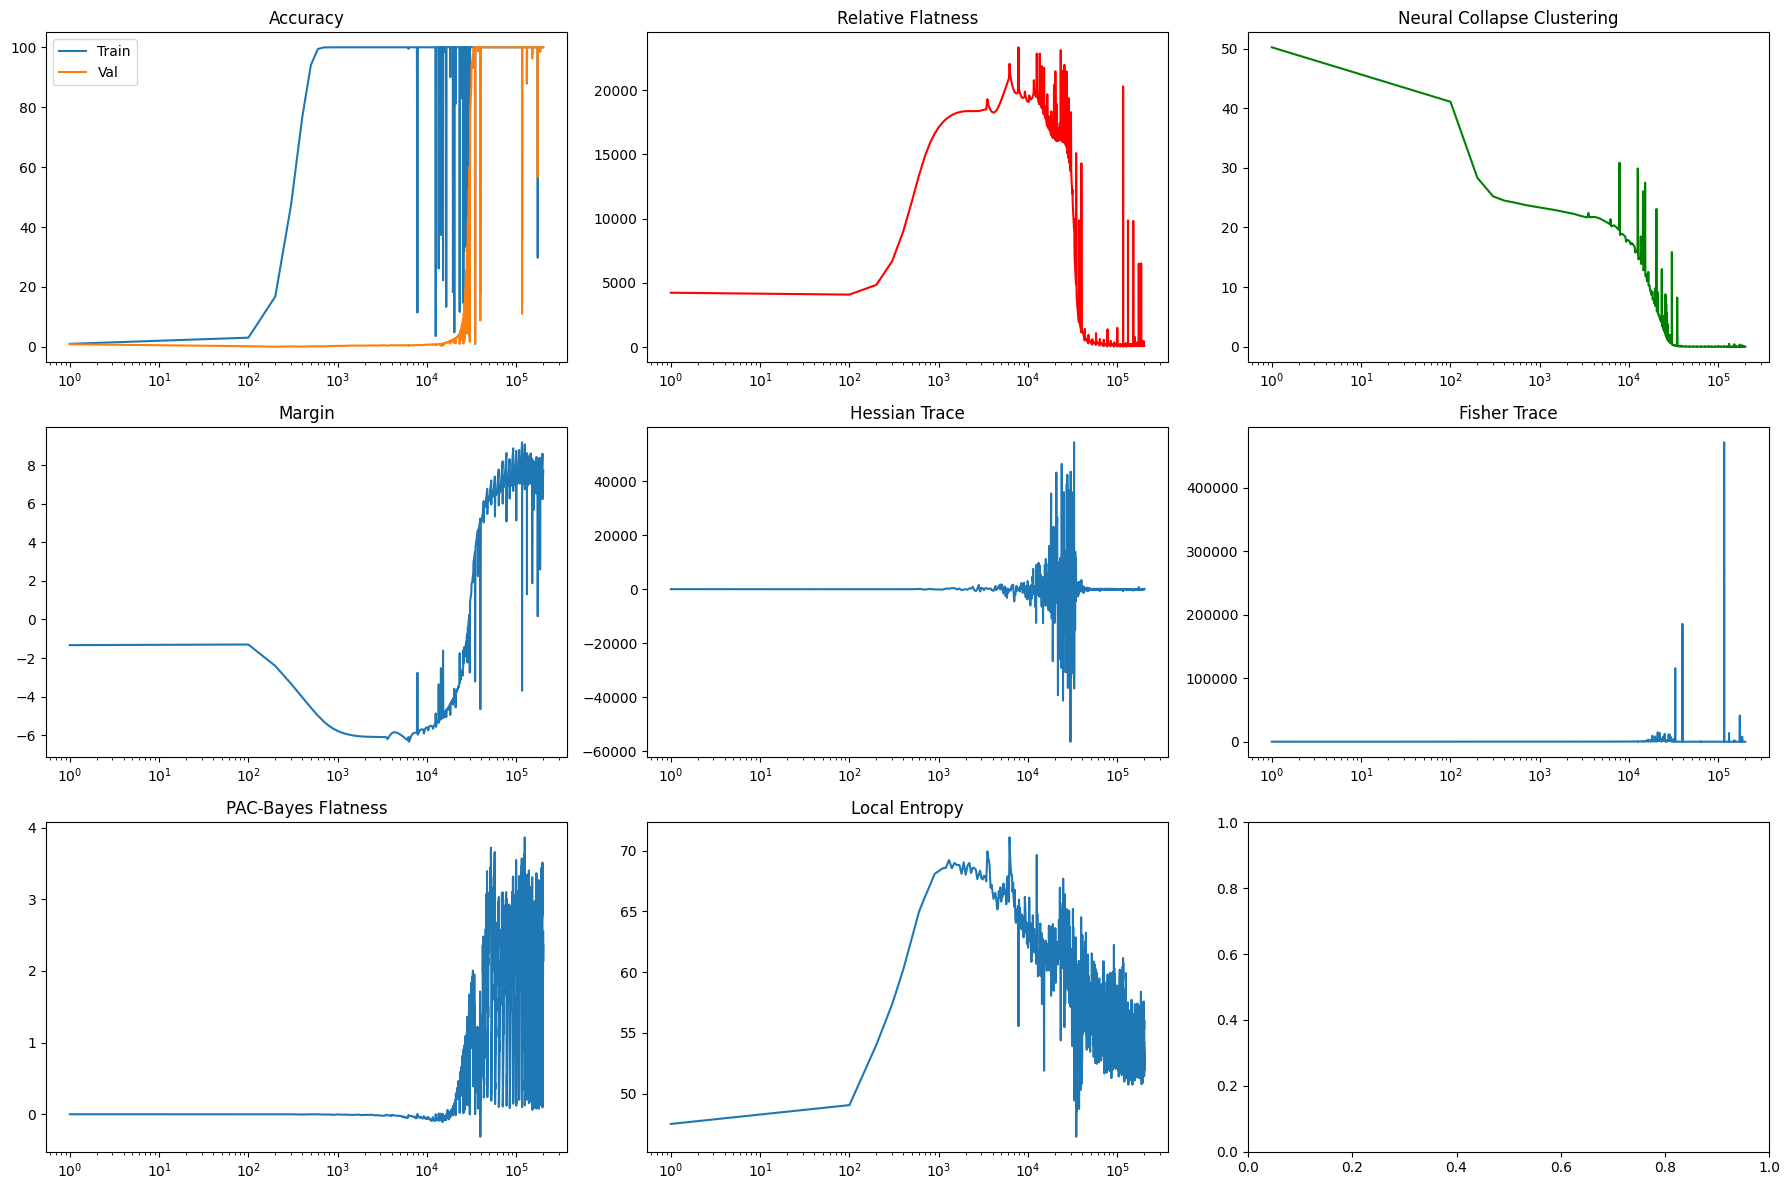

In [22]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(3,3, figsize=(18,12))

steps = np.arange(len(train_acc))*100
steps[0]=1

# Accuracy
axes[0,0].plot(steps,np.array(train_acc)*100,label="Train")
axes[0,0].plot(steps,np.array(val_acc)*100,label="Val")
axes[0,0].set_xscale("log")
axes[0,0].set_title("Accuracy")
axes[0,0].legend()

# Relative Flatness
axes[0,1].plot(steps,flatness,color="red")
axes[0,1].set_xscale("log")
axes[0,1].set_title("Relative Flatness")

# NCC
axes[0,2].plot(steps,ncc,color="green")
axes[0,2].set_xscale("log")
axes[0,2].set_title("Neural Collapse Clustering")

# Margin
axes[1,0].plot(steps,margin_vals)
axes[1,0].set_xscale("log")
axes[1,0].set_title("Margin")

# Hessian Trace
axes[1,1].plot(steps,hessian_vals)
axes[1,1].set_xscale("log")
axes[1,1].set_title("Hessian Trace")

# Fisher
axes[1,2].plot(steps,fisher_vals)
axes[1,2].set_xscale("log")
axes[1,2].set_title("Fisher Trace")

# PAC-Bayes
axes[2,0].plot(steps,pac_vals)
axes[2,0].set_xscale("log")
axes[2,0].set_title("PAC-Bayes Flatness")

# Local Entropy
axes[2,1].plot(steps,entropy_vals)
axes[2,1].set_xscale("log")
axes[2,1].set_title("Local Entropy")

plt.tight_layout()
plt.show()

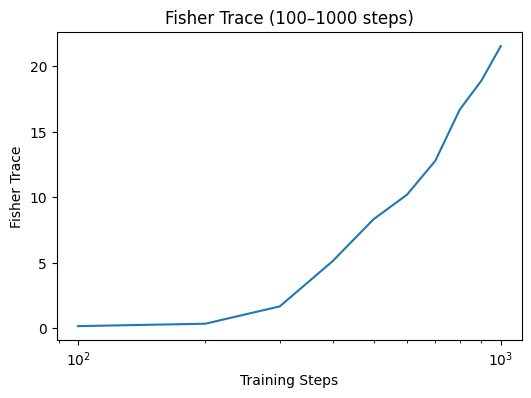

In [24]:
import matplotlib.pyplot as plt
import numpy as np

steps = np.arange(len(fisher_vals)) * 100
steps[0] = 1

mask = (steps >= 100) & (steps <= 1000)

plt.figure(figsize=(6,4))
plt.plot(steps[mask], np.array(fisher_vals)[mask])
plt.xscale("log")
plt.xlabel("Training Steps")
plt.ylabel("Fisher Trace")
plt.title("Fisher Trace (100–1000 steps)")
plt.show()

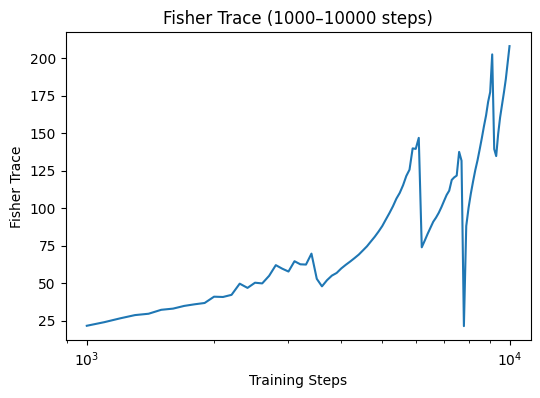

In [26]:
import matplotlib.pyplot as plt
import numpy as np

steps = np.arange(len(fisher_vals)) * 100
steps[0] = 1

mask = (steps >= 1000) & (steps <= 10000)

plt.figure(figsize=(6,4))
plt.plot(steps[mask], np.array(fisher_vals)[mask])
plt.xscale("log")
plt.xlabel("Training Steps")
plt.ylabel("Fisher Trace")
plt.title("Fisher Trace (1000–10000 steps)")
plt.show()

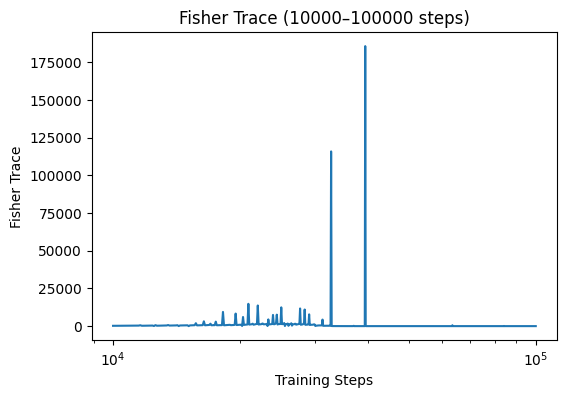

In [28]:
import matplotlib.pyplot as plt
import numpy as np

steps = np.arange(len(fisher_vals)) * 100
steps[0] = 1

mask = (steps >= 10000) & (steps <= 100000)

plt.figure(figsize=(6,4))
plt.plot(steps[mask], np.array(fisher_vals)[mask])
plt.xscale("log")
plt.xlabel("Training Steps")
plt.ylabel("Fisher Trace")
plt.title("Fisher Trace (10000–100000 steps)")
plt.show()

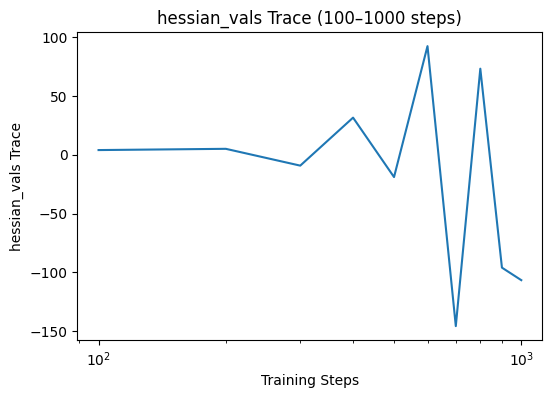

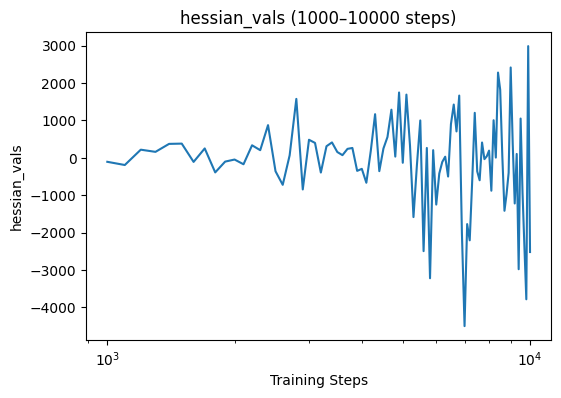

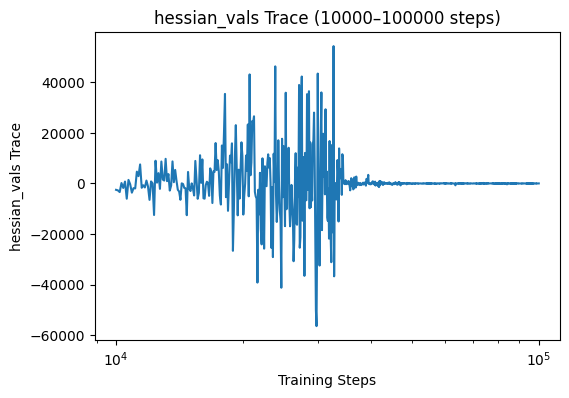

In [36]:
import matplotlib.pyplot as plt
import numpy as np

steps = np.arange(len(hessian_vals)) * 100
steps[0] = 1

mask = (steps >= 100) & (steps <= 1000)

plt.figure(figsize=(6,4))
plt.plot(steps[mask], np.array(hessian_vals)[mask])
plt.xscale("log")
plt.xlabel("Training Steps")
plt.ylabel("hessian_vals Trace")
plt.title("hessian_vals Trace (100–1000 steps)")
plt.show()

import matplotlib.pyplot as plt
import numpy as np

steps = np.arange(len(hessian_vals)) * 100
steps[0] = 1

mask = (steps >= 1000) & (steps <= 10000)

plt.figure(figsize=(6,4))
plt.plot(steps[mask], np.array(hessian_vals)[mask])
plt.xscale("log")
plt.xlabel("Training Steps")
plt.ylabel("hessian_vals")
plt.title("hessian_vals (1000–10000 steps)")
plt.show()

import matplotlib.pyplot as plt
import numpy as np

steps = np.arange(len(hessian_vals)) * 100
steps[0] = 1

mask = (steps >= 10000) & (steps <= 100000)

plt.figure(figsize=(6,4))
plt.plot(steps[mask], np.array(hessian_vals)[mask])
plt.xscale("log")
plt.xlabel("Training Steps")
plt.ylabel("hessian_vals Trace")
plt.title("hessian_vals Trace (10000–100000 steps)")
plt.show()

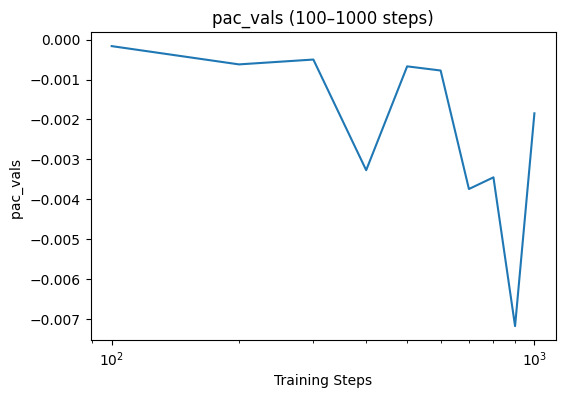

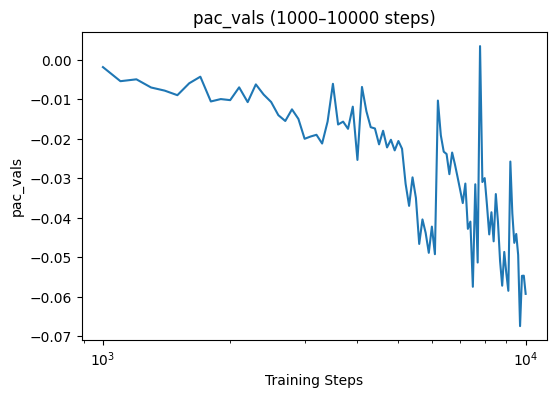

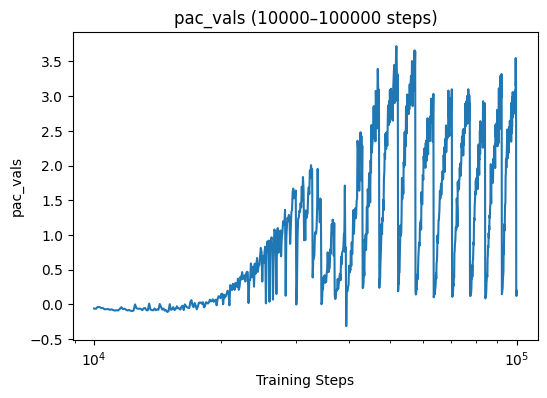

In [35]:
import matplotlib.pyplot as plt
import numpy as np

steps = np.arange(len(pac_vals)) * 100
steps[0] = 1

mask = (steps >= 100) & (steps <= 1000)

plt.figure(figsize=(6,4))
plt.plot(steps[mask], np.array(pac_vals)[mask])
plt.xscale("log")
plt.xlabel("Training Steps")
plt.ylabel("pac_vals ")
plt.title("pac_vals (100–1000 steps)")
plt.show()

import matplotlib.pyplot as plt
import numpy as np

steps = np.arange(len(pac_vals)) * 100
steps[0] = 1

mask = (steps >= 1000) & (steps <= 10000)

plt.figure(figsize=(6,4))
plt.plot(steps[mask], np.array(pac_vals)[mask])
plt.xscale("log")
plt.xlabel("Training Steps")
plt.ylabel("pac_vals")
plt.title("pac_vals (1000–10000 steps)")
plt.show()

import matplotlib.pyplot as plt
import numpy as np

steps = np.arange(len(pac_vals)) * 100
steps[0] = 1

mask = (steps >= 10000) & (steps <= 100000)

plt.figure(figsize=(6,4))
plt.plot(steps[mask], np.array(pac_vals)[mask])
plt.xscale("log")
plt.xlabel("Training Steps")
plt.ylabel("pac_vals")
plt.title("pac_vals (10000–100000 steps)")
plt.show()

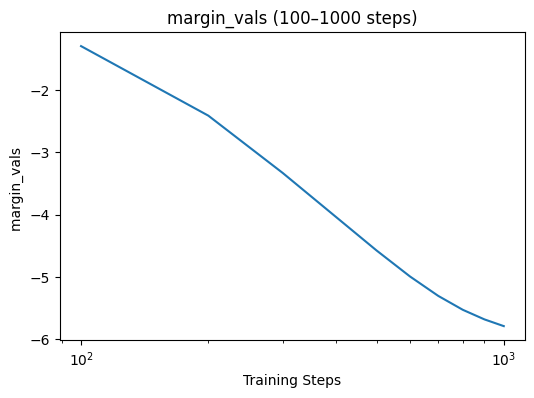

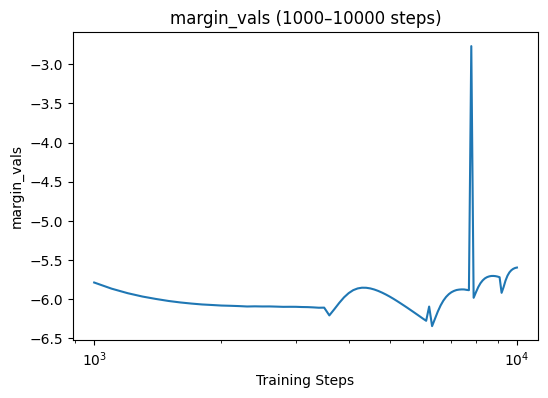

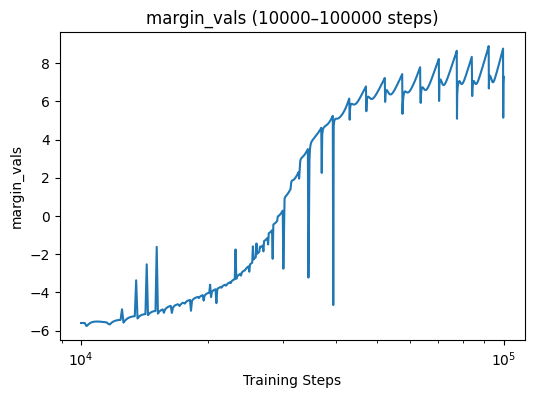

In [34]:
import matplotlib.pyplot as plt
import numpy as np

steps = np.arange(len(margin_vals)) * 100
steps[0] = 1

mask = (steps >= 100) & (steps <= 1000)

plt.figure(figsize=(6,4))
plt.plot(steps[mask], np.array(margin_vals)[mask])
plt.xscale("log")
plt.xlabel("Training Steps")
plt.ylabel("margin_vals ")
plt.title("margin_vals (100–1000 steps)")
plt.show()

import matplotlib.pyplot as plt
import numpy as np

steps = np.arange(len(margin_vals)) * 100
steps[0] = 1

mask = (steps >= 1000) & (steps <= 10000)

plt.figure(figsize=(6,4))
plt.plot(steps[mask], np.array(margin_vals)[mask])
plt.xscale("log")
plt.xlabel("Training Steps")
plt.ylabel("margin_vals")
plt.title("margin_vals (1000–10000 steps)")
plt.show()

import matplotlib.pyplot as plt
import numpy as np

steps = np.arange(len(margin_vals)) * 100
steps[0] = 1

mask = (steps >= 10000) & (steps <= 100000)

plt.figure(figsize=(6,4))
plt.plot(steps[mask], np.array(margin_vals)[mask])
plt.xscale("log")
plt.xlabel("Training Steps")
plt.ylabel("margin_vals")
plt.title("margin_vals (10000–100000 steps)")
plt.show()

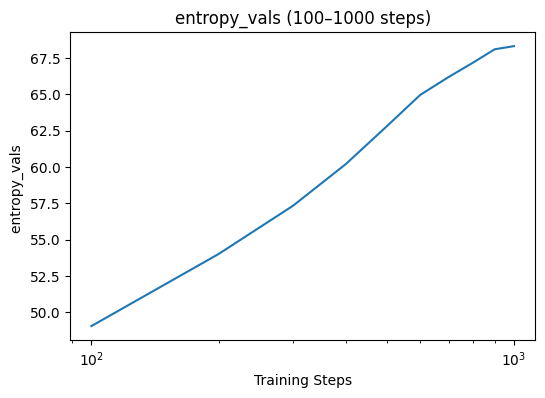

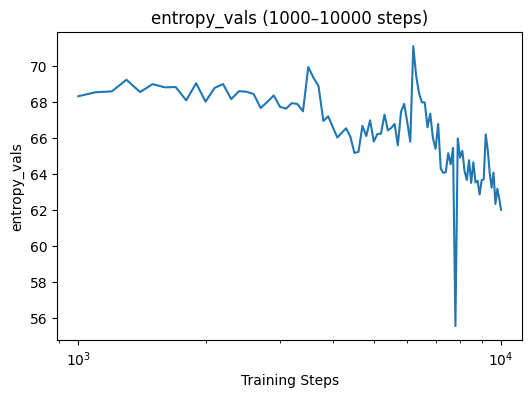

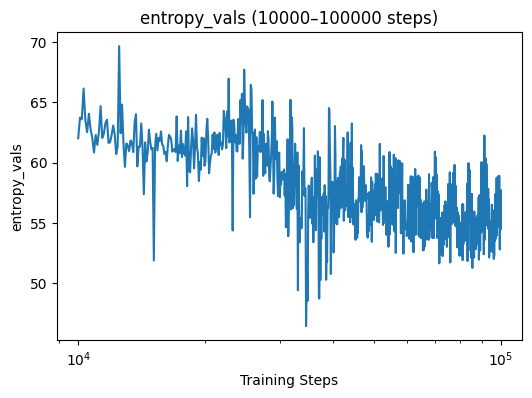

In [33]:
import matplotlib.pyplot as plt
import numpy as np

steps = np.arange(len(entropy_vals)) * 100
steps[0] = 1

mask = (steps >= 100) & (steps <= 1000)

plt.figure(figsize=(6,4))
plt.plot(steps[mask], np.array(entropy_vals)[mask])
plt.xscale("log")
plt.xlabel("Training Steps")
plt.ylabel("entropy_vals ")
plt.title("entropy_vals (100–1000 steps)")
plt.show()

import matplotlib.pyplot as plt
import numpy as np

steps = np.arange(len(entropy_vals)) * 100
steps[0] = 1

mask = (steps >= 1000) & (steps <= 10000)

plt.figure(figsize=(6,4))
plt.plot(steps[mask], np.array(entropy_vals)[mask])
plt.xscale("log")
plt.xlabel("Training Steps")
plt.ylabel("entropy_vals")
plt.title("entropy_vals (1000–10000 steps)")
plt.show()

import matplotlib.pyplot as plt
import numpy as np

steps = np.arange(len(entropy_vals)) * 100
steps[0] = 1

mask = (steps >= 10000) & (steps <= 100000)

plt.figure(figsize=(6,4))
plt.plot(steps[mask], np.array(entropy_vals)[mask])
plt.xscale("log")
plt.xlabel("Training Steps")
plt.ylabel("entropy_vals")
plt.title("entropy_vals (10000–100000 steps)")
plt.show()

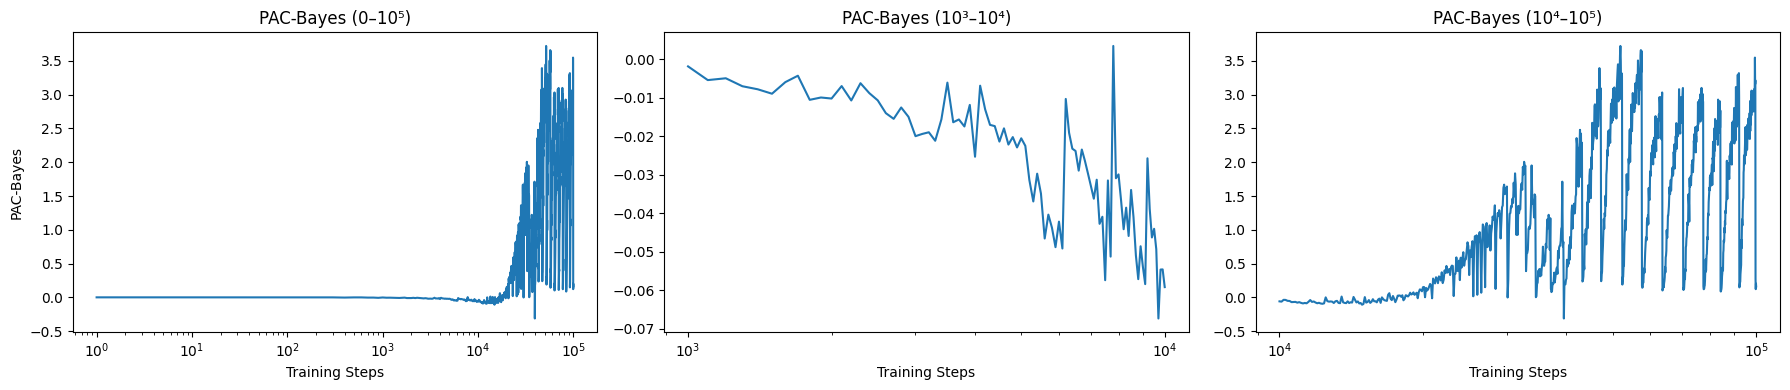

In [37]:
import matplotlib.pyplot as plt
import numpy as np

steps = np.arange(len(pac_vals)) * 100
steps[0] = 1

fig, axes = plt.subplots(1, 3, figsize=(18,4))

# 0 – 10^5
mask1 = (steps >= 0) & (steps <= 100000)
axes[0].plot(steps[mask1], np.array(pac_vals)[mask1])
axes[0].set_xscale("log")
axes[0].set_title("PAC-Bayes (0–10⁵)")
axes[0].set_xlabel("Training Steps")
axes[0].set_ylabel("PAC-Bayes")

# 1000 – 10000
mask2 = (steps >= 1000) & (steps <= 10000)
axes[1].plot(steps[mask2], np.array(pac_vals)[mask2])
axes[1].set_xscale("log")
axes[1].set_title("PAC-Bayes (10³–10⁴)")
axes[1].set_xlabel("Training Steps")

# 10000 – 100000
mask3 = (steps >= 10000) & (steps <= 100000)
axes[2].plot(steps[mask3], np.array(pac_vals)[mask3])
axes[2].set_xscale("log")
axes[2].set_title("PAC-Bayes (10⁴–10⁵)")
axes[2].set_xlabel("Training Steps")

plt.tight_layout()
plt.show()

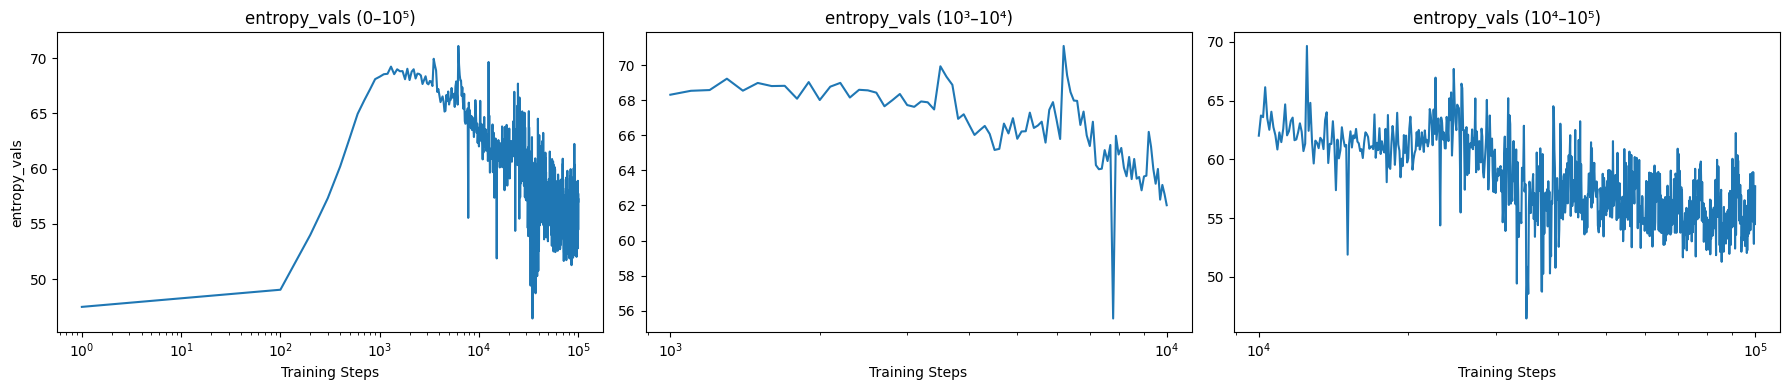

In [38]:
import matplotlib.pyplot as plt
import numpy as np

steps = np.arange(len(entropy_vals)) * 100
steps[0] = 1

fig, axes = plt.subplots(1, 3, figsize=(18,4))

# 0 – 10^5
mask1 = (steps >= 0) & (steps <= 100000)
axes[0].plot(steps[mask1], np.array(entropy_vals)[mask1])
axes[0].set_xscale("log")
axes[0].set_title("entropy_vals (0–10⁵)")
axes[0].set_xlabel("Training Steps")
axes[0].set_ylabel("entropy_vals")

# 1000 – 10000
mask2 = (steps >= 1000) & (steps <= 10000)
axes[1].plot(steps[mask2], np.array(entropy_vals)[mask2])
axes[1].set_xscale("log")
axes[1].set_title("entropy_vals (10³–10⁴)")
axes[1].set_xlabel("Training Steps")

# 10000 – 100000
mask3 = (steps >= 10000) & (steps <= 100000)
axes[2].plot(steps[mask3], np.array(entropy_vals)[mask3])
axes[2].set_xscale("log")
axes[2].set_title("entropy_vals (10⁴–10⁵)")
axes[2].set_xlabel("Training Steps")

plt.tight_layout()
plt.show()

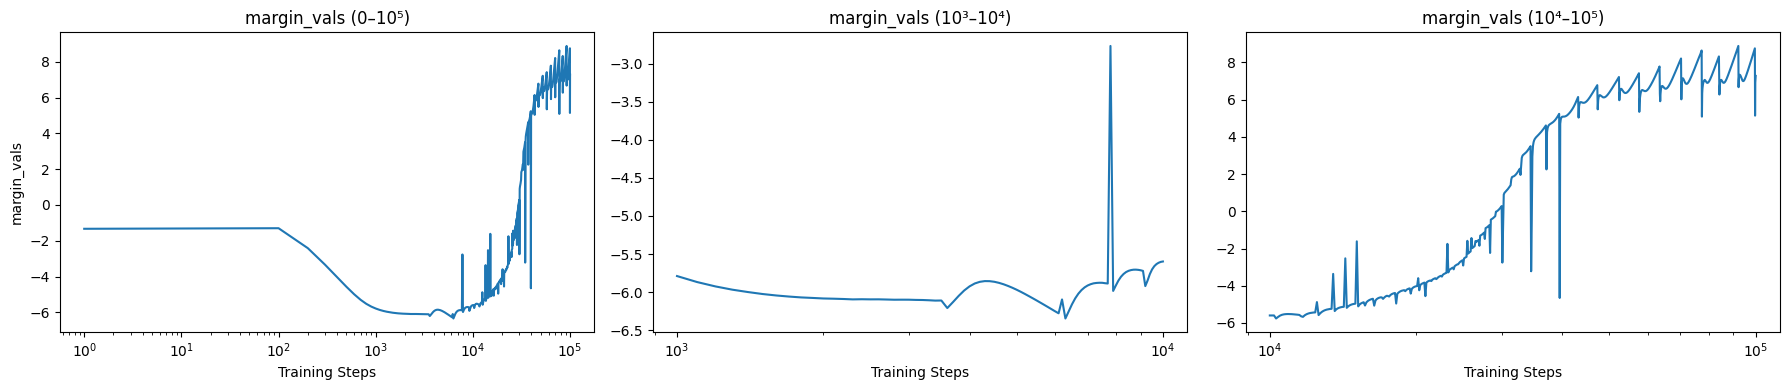

In [41]:
import matplotlib.pyplot as plt
import numpy as np

steps = np.arange(len(margin_vals)) * 100
steps[0] = 1

fig, axes = plt.subplots(1, 3, figsize=(18,4))

# 0 – 10^5
mask1 = (steps >= 0) & (steps <= 100000)
axes[0].plot(steps[mask1], np.array(margin_vals)[mask1])
axes[0].set_xscale("log")
axes[0].set_title("margin_vals (0–10⁵)")
axes[0].set_xlabel("Training Steps")
axes[0].set_ylabel("margin_vals")

# 1000 – 10000
mask2 = (steps >= 1000) & (steps <= 10000)
axes[1].plot(steps[mask2], np.array(margin_vals)[mask2])
axes[1].set_xscale("log")
axes[1].set_title("margin_vals (10³–10⁴)")
axes[1].set_xlabel("Training Steps")

# 10000 – 100000
mask3 = (steps >= 10000) & (steps <= 100000)
axes[2].plot(steps[mask3], np.array(margin_vals)[mask3])
axes[2].set_xscale("log")
axes[2].set_title("margin_vals (10⁴–10⁵)")
axes[2].set_xlabel("Training Steps")

plt.tight_layout()
plt.show()

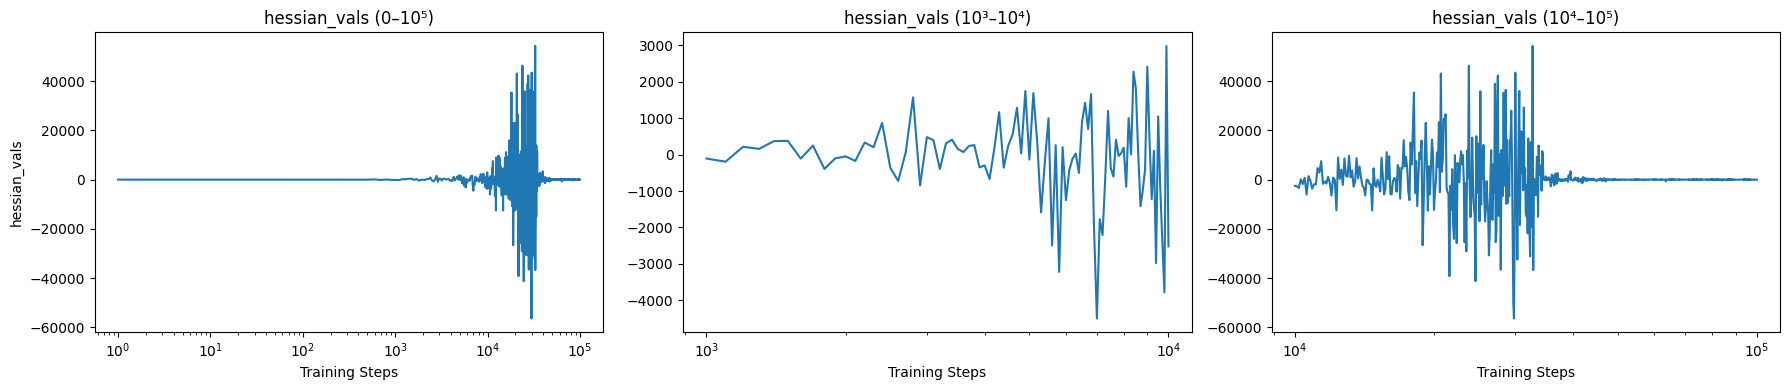

In [40]:
import matplotlib.pyplot as plt
import numpy as np

steps = np.arange(len(hessian_vals)) * 100
steps[0] = 1

fig, axes = plt.subplots(1, 3, figsize=(18,4))

# 0 – 10^5
mask1 = (steps >= 0) & (steps <= 100000)
axes[0].plot(steps[mask1], np.array(hessian_vals)[mask1])
axes[0].set_xscale("log")
axes[0].set_title("hessian_vals (0–10⁵)")
axes[0].set_xlabel("Training Steps")
axes[0].set_ylabel("hessian_vals")

# 1000 – 10000
mask2 = (steps >= 1000) & (steps <= 10000)
axes[1].plot(steps[mask2], np.array(hessian_vals)[mask2])
axes[1].set_xscale("log")
axes[1].set_title("hessian_vals (10³–10⁴)")
axes[1].set_xlabel("Training Steps")

# 10000 – 100000
mask3 = (steps >= 10000) & (steps <= 100000)
axes[2].plot(steps[mask3], np.array(hessian_vals)[mask3])
axes[2].set_xscale("log")
axes[2].set_title("hessian_vals (10⁴–10⁵)")
axes[2].set_xlabel("Training Steps")

plt.tight_layout()
plt.show()

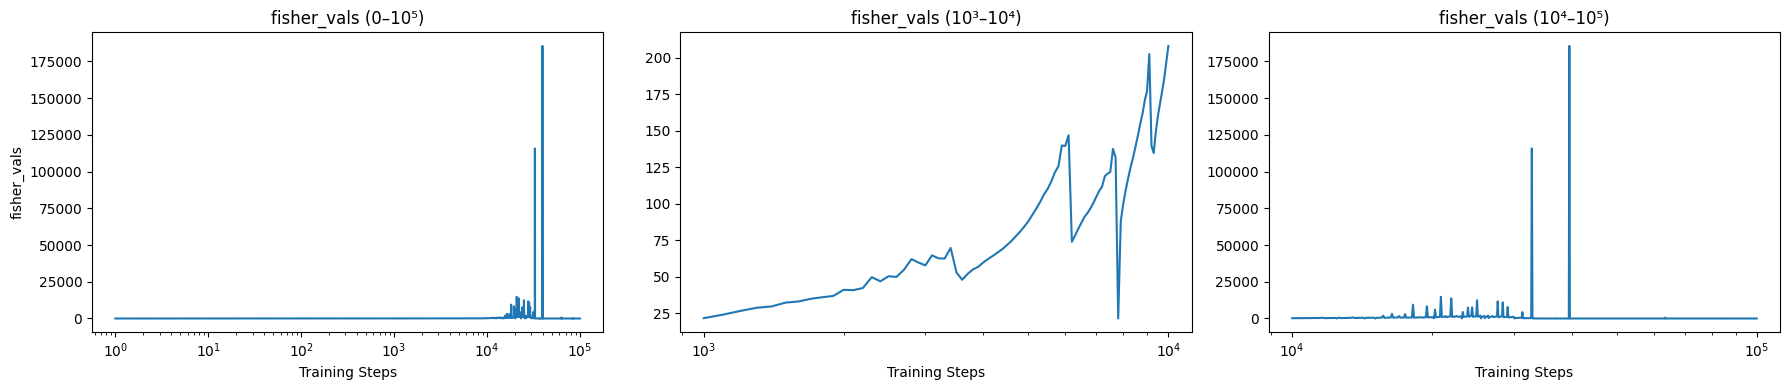

In [42]:
import matplotlib.pyplot as plt
import numpy as np

steps = np.arange(len(fisher_vals)) * 100
steps[0] = 1

fig, axes = plt.subplots(1, 3, figsize=(18,4))

# 0 – 10^5
mask1 = (steps >= 0) & (steps <= 100000)
axes[0].plot(steps[mask1], np.array(fisher_vals)[mask1])
axes[0].set_xscale("log")
axes[0].set_title("fisher_vals (0–10⁵)")
axes[0].set_xlabel("Training Steps")
axes[0].set_ylabel("fisher_vals")

# 1000 – 10000
mask2 = (steps >= 1000) & (steps <= 10000)
axes[1].plot(steps[mask2], np.array(fisher_vals)[mask2])
axes[1].set_xscale("log")
axes[1].set_title("fisher_vals (10³–10⁴)")
axes[1].set_xlabel("Training Steps")

# 10000 – 100000
mask3 = (steps >= 10000) & (steps <= 100000)
axes[2].plot(steps[mask3], np.array(fisher_vals)[mask3])
axes[2].set_xscale("log")
axes[2].set_title("fisher_vals (10⁴–10⁵)")
axes[2].set_xlabel("Training Steps")

plt.tight_layout()
plt.show()